In [1]:
import pandas as pd
import dtale
import numpy as np
import seaborn as sns
from statsmodels.iolib.summary import summary
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

In [2]:
df = pd.read_csv("steam_all_rev.csv")
#print(df.head())

In [3]:
import datetime
df2 = df.copy()
#Date Cleaning
df2['release_date'].dtype
df2['release_date'] = pd.to_datetime(df2['release_date'])
df2['release_year']= df2['release_date'].dt.year
print(df2['release_year'])


#df['release_date'] = pd.to_datetime(df['release_date'])
#print(df['release_date'])
#df['release_date'] = pd.to_datetime(df['release_date'])
#print(df.head())


0        2000
1        2003
2        1999
3        1998
4        2004
         ... 
26863    2019
26864    2019
26865    2019
26866    2019
26867    2019
Name: release_year, Length: 26868, dtype: int32


In [4]:
#Platforms:
df2['platforms'].dtype
df2['platforms'] = df2['platforms'].str.split(';')
df2['windows_sup'] = df2['platforms'].apply(lambda x: 1 if 'windows' in x else 0)
df2['mac_sup'] = df2['platforms'].apply(lambda x: 1 if 'mac' in x else 0)
df2['linux_sup'] = df2['platforms'].apply(lambda x: 1 if 'linux' in x else 0)
print(df2.iloc[:,-20:])

      release_date  english           developer             publisher  \
0       2000-11-01        1               Valve                 Valve   
1       2003-05-01        1               Valve                 Valve   
2       1999-11-01        1    Gearbox Software                 Valve   
3       1998-11-08        1               Valve                 Valve   
4       2004-03-01        1               Valve                 Valve   
...            ...      ...                 ...                   ...   
26863   2019-04-24        1         SHEN JIAWEI           SHEN JIAWEI   
26864   2019-04-23        1      Semyon Maximov      BekkerDev Studio   
26865   2019-04-24        1         EntwicklerX           EntwicklerX   
26866   2019-04-17        1  Yustas Game Studio  Alawar Entertainment   
26867   2019-04-24        1    Adept Studios GD  Alawar Entertainment   

                   platforms  required_age  \
0      [windows, mac, linux]             0   
1      [windows, mac, linux]   

In [5]:
import itertools

#Genres
df2['genres'] = df2['genres'].str.split(';')
unique_gen = np.unique([*itertools.chain.from_iterable(df2['genres'])])
print(unique_gen)

for i in unique_gen:
    df2[i+"_genre"] = df2['genres'].apply(lambda x: 1 if i in x else 0)


['Accounting' 'Action' 'Adventure' 'Animation & Modeling'
 'Audio Production' 'Casual' 'Design & Illustration' 'Documentary'
 'Early Access' 'Education' 'Free to Play' 'Game Development' 'Gore'
 'Indie' 'Massively Multiplayer' 'Nudity' 'Photo Editing' 'RPG' 'Racing'
 'Sexual Content' 'Simulation' 'Software Training' 'Sports' 'Strategy'
 'Tutorial' 'Utilities' 'Video Production' 'Violent' 'Web Publishing']


In [6]:
#Categories:
df2['categories'] = df2['categories'].str.split(';')
unique_cat = np.unique([*itertools.chain.from_iterable(df2['categories'])])
print(unique_cat)

for i in unique_cat:
    df2[i+"_cat"] = df2['categories'].apply(lambda x: 1 if i in x else 0)

['Captions available' 'Co-op' 'Commentary available'
 'Cross-Platform Multiplayer' 'Full controller support' 'In-App Purchases'
 'Includes Source SDK' 'Includes level editor' 'Local Co-op'
 'Local Multi-Player' 'MMO' 'Mods' 'Mods (require HL2)' 'Multi-player'
 'Online Co-op' 'Online Multi-Player' 'Partial Controller Support'
 'Shared/Split Screen' 'Single-player' 'Stats' 'Steam Achievements'
 'Steam Cloud' 'Steam Leaderboards' 'Steam Trading Cards'
 'Steam Turn Notifications' 'Steam Workshop' 'SteamVR Collectibles'
 'VR Support' 'Valve Anti-Cheat enabled']


In [7]:
print(df2.iloc[:,-60:])

       mac_sup  linux_sup  Accounting_genre  Action_genre  Adventure_genre  \
0            1          1                 0             1                0   
1            1          1                 0             1                0   
2            1          1                 0             1                0   
3            1          1                 0             1                0   
4            1          1                 0             1                0   
...        ...        ...               ...           ...              ...   
26863        0          0                 0             0                1   
26864        0          0                 0             1                1   
26865        0          0                 0             1                0   
26866        1          0                 0             0                1   
26867        1          0                 0             0                1   

       Animation & Modeling_genre  Audio Production_genre  Casu

In [8]:
#Add rating proportion
df2['pos_prop'] = df2['positive_ratings']/(df2['positive_ratings'] + df2['negative_ratings'])
print(df2['pos_prop'].head())

df2['pos_prop'].describe()
#Plot:
#sns.histplot((df2['pos_prop']))

# Adding labels and title
#plt.xlabel('pos_prop')
#plt.ylabel('Density')
#plt.title('overall_rating_proportions')

# Display the plot
#plt.show()


0    0.973888
1    0.895648
2    0.947996
3    0.961878
4    0.893871
Name: pos_prop, dtype: float64


count    26868.000000
mean         0.714440
std          0.233950
min          0.000000
25%          0.583333
50%          0.760472
75%          0.894236
max          1.000000
Name: pos_prop, dtype: float64

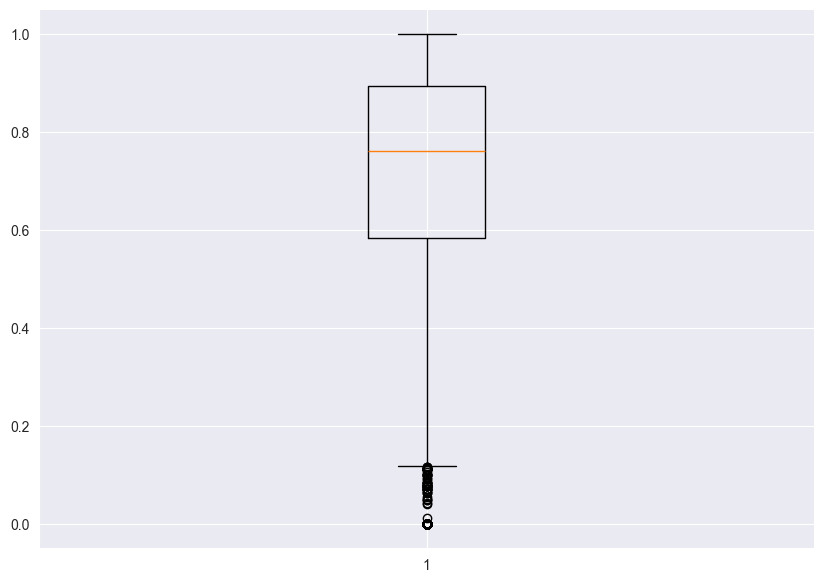

In [9]:
#Boxplot:
pos_prop= df2['pos_prop']
fig = plt.figure(figsize = (10,7))
plt.boxplot(pos_prop)
plt.show()